# 03 · Stationarity

Every forecast rests on the same assumption: **the past is a guide to the future**. If the rules that generate a series keep changing, averages computed from history estimate a moving target, and a model fitted to yesterday describes a world that's gone. *Stationarity* is the formal version of "the rules don't change". Most classical models, including the ARMA family in chapters 06–07, require it.

This chapter is careful about what stationarity does and does *not* mean, because the idea is easy to get wrong. In particular, **a series can be strongly autocorrelated and still be perfectly stationary**.

**By the end of this chapter you will be able to**

- state the definition of (weak) stationarity and recognise the common ways it fails
- explain the difference between a **random walk** and a **mean-reverting** process, and measure how quickly shocks fade
- run and interpret the **ADF** and **KPSS** tests together, and know what each is blind to
- understand from simulation how **reliable** these tests are
- choose the right transformation (**differencing**, **detrending**, **seasonal differencing**) and spot **over-differencing**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.signal import lfilter
from statsmodels.tsa.stattools import acf

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 3)

---
## 1. What stationarity means

A series $y_t$ is **(weakly) stationary** if three things stay fixed over time:

1. **Mean:** $\;E[y_t] = \mu$ for every $t$
2. **Variance:** $\;\operatorname{Var}(y_t) = \sigma^2$ for every $t$
3. **Autocovariance depends only on the lag:** $\;\operatorname{Cov}(y_t, y_{t+k}) = \gamma_k$, the same for every $t$

Condition 3 is the one people misread. It does **not** say that $y_t$ must be uncorrelated with its past. It says the *strength* of that relationship, how much today resembles yesterday, must be the same in 2010 as in 2015. Autocorrelation is allowed. Autocorrelation that changes over time is not.

(There's also *strict* stationarity, which requires the entire joint distribution to be time-invariant. In practice "stationary" almost always means the weak version above.)

---
## 2. A gallery of processes

We'll generate six series from the **same random shocks** $\varepsilon_t \sim N(0, 1)$, so any difference between them comes from structure alone.

| Series | Recipe | Stationary? |
|---|---|---|
| White noise | $y_t = \varepsilon_t$ | ✅ |
| AR(1), $\phi = 0.7$ | $y_t = 0.7\,y_{t-1} + \varepsilon_t$ | ✅ autocorrelated, but it keeps returning to 0 |
| Random walk | $y_t = y_{t-1} + \varepsilon_t$ | ❌ variance grows without limit |
| Trend + noise | $y_t = 0.05\,t + \varepsilon_t$ | ❌ mean changes; **trend-stationary** |
| Variance shift | $y_t = \sigma_t\,\varepsilon_t$, $\sigma_t$ jumps from 1 to 3 | ❌ variance changes |
| Seasonal | $y_t = 5\sin(2\pi t/12) + \varepsilon_t$ | ❌ mean depends on the time of year |

`scipy.signal.lfilter` applies a recursion like $y_t = \phi y_{t-1} + \varepsilon_t$ to a whole array at once, which is much faster than a Python loop. We'll lean on it for the simulations later.

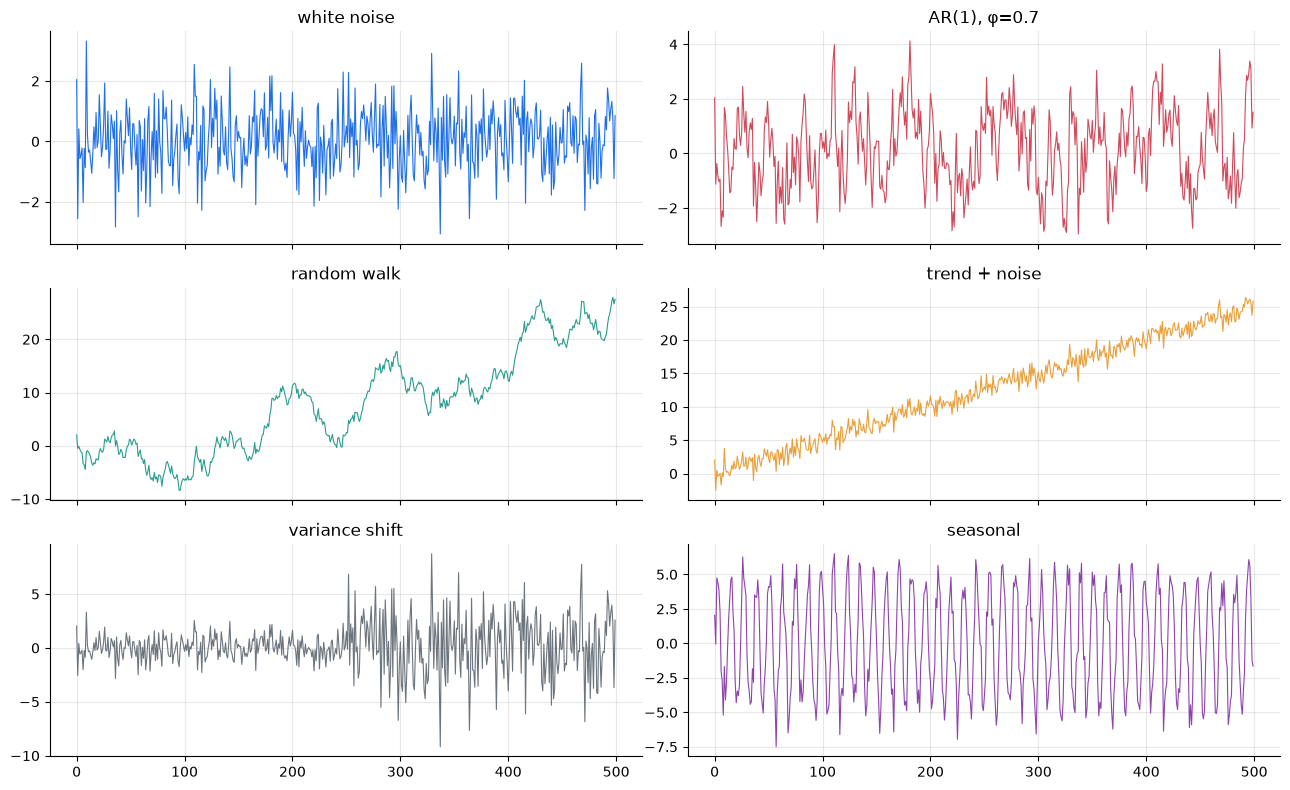

In [2]:
def ar1(shocks, phi):
    """y_t = phi * y_{t-1} + shock_t, starting from 0 (works along the last axis)."""
    return lfilter([1], [1, -phi], shocks, axis=-1)

rng = np.random.default_rng(3)
n = 500
t = np.arange(n)
eps = rng.normal(size=n)

gallery = pd.DataFrame({
    "white noise": eps,
    "AR(1), φ=0.7": ar1(eps, 0.7),
    "random walk": ar1(eps, 1.0),
    "trend + noise": 0.05 * t + eps,
    "variance shift": eps * np.where(t < n // 2, 1, 3),
    "seasonal": 5 * np.sin(2 * np.pi * t / 12) + eps,
})

axes = gallery.plot(subplots=True, layout=(3, 2), figsize=(13, 8), legend=False, lw=0.8)
for ax, name in zip(axes.flat, gallery.columns):
    ax.set_title(name)
plt.tight_layout();

Look at the random walk. With nothing but zero-mean shocks, it wanders far from zero, and a single path can easily *look* as if it has a trend. That's one of the most important things to internalise in time-series work: **random walks produce convincing fake trends**. The AR(1) uses exactly the same shocks, but its $\phi = 0.7$ pulls it back towards zero every step, so it never gets far.

---
## 3. The ensemble view: why a random walk isn't stationary

A single path can mislead, so let's simulate **a thousand** of each and look at the spread across paths at every point in time. For a random walk started at 0, $y_t$ is the sum of $t$ independent shocks, so $\operatorname{Var}(y_t) = t\,\sigma^2$: the variance grows linearly and never settles. For an AR(1) with $|\phi| < 1$, the variance settles at $\sigma^2 / (1 - \phi^2)$.

,random walk: variance,theory (t + 1),AR(1): variance,theory 1/(1-φ²)
t,,,,
10,12.088,11,2.149,1.961
100,108.185,101,1.974,1.961
499,492.914,500,1.855,1.961


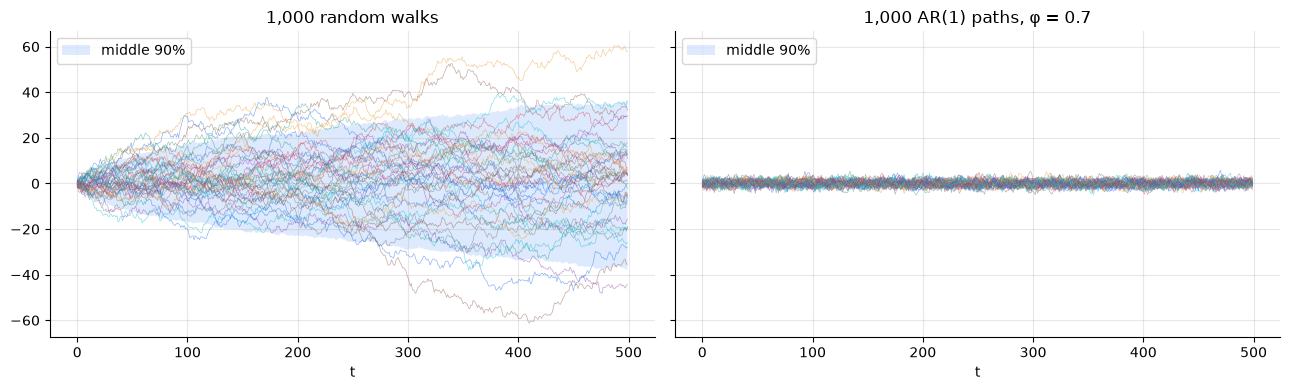

In [3]:
paths_shocks = rng.normal(size=(1000, n))
walks = ar1(paths_shocks, 1.0)
ar_paths = ar1(paths_shocks, 0.7)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, paths, title in [(axes[0], walks, "1,000 random walks"),
                         (axes[1], ar_paths, "1,000 AR(1) paths, φ = 0.7")]:
    ax.plot(t, paths[:40].T, lw=0.5, alpha=0.5)
    ax.fill_between(t, *np.percentile(paths, [5, 95], axis=0), alpha=0.15, label="middle 90%")
    ax.set(title=title, xlabel="t")
    ax.legend(loc="upper left")
fig.tight_layout()

checkpoints = [10, 100, 499]
pd.DataFrame({
    "random walk: variance": walks[:, checkpoints].var(axis=0),
    "theory (t + 1)": [c + 1 for c in checkpoints],
    "AR(1): variance": ar_paths[:, checkpoints].var(axis=0),
    "theory 1/(1-φ²)": 1 / (1 - 0.7**2),
}, index=pd.Index(checkpoints, name="t"))

The simulated variances match the theory. (The random walk's variance is $t + 1$ here because our arrays start counting at $t = 0$ with one shock already added.) The random walk's funnel keeps widening, and **uncertainty about where it will be grows with the horizon, forever**. That's exactly what forecast intervals for non-stationary series look like later in the course.

---
## 4. Persistence: how long do shocks last?

In an AR(1), a shock of size 1 today is still worth $\phi^k$ after $k$ steps. That gives a useful summary, the **half-life**: the number of steps until a shock has lost half its effect,

$$h = \frac{\ln 0.5}{\ln \phi}.$$

At $\phi = 1$ the shock never fades. That's what a **unit root** means: $\phi$ sits exactly at 1, and the series has no mean to return to.

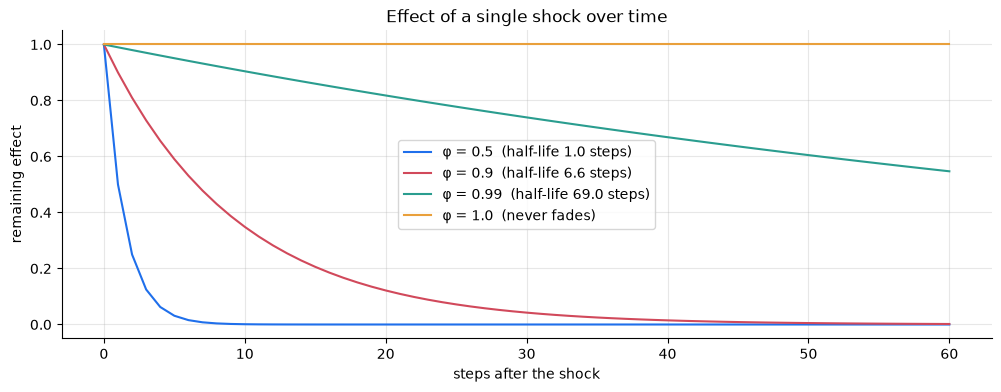

In [4]:
steps = np.arange(0, 61)
fig, ax = plt.subplots()
for phi in [0.5, 0.9, 0.99, 1.0]:
    label = f"φ = {phi}" + (f"  (half-life {np.log(0.5) / np.log(phi):.1f} steps)" if phi < 1 else "  (never fades)")
    ax.plot(steps, phi ** steps, label=label)
ax.set(title="Effect of a single shock over time", xlabel="steps after the shock", ylabel="remaining effect")
ax.legend();

Notice how different $\phi = 0.99$ and $\phi = 1$ are *in principle* (one reverts eventually, the other never does) and how similar they look over any short window. Keep that picture in mind for section 6.

---
## 5. Look before you test

Rolling statistics are the quickest check. If the rolling mean or rolling standard deviation clearly drifts, the series is not stationary. It's a screening tool rather than proof, because a stationary series with strong autocorrelation also produces a wobbly rolling mean.

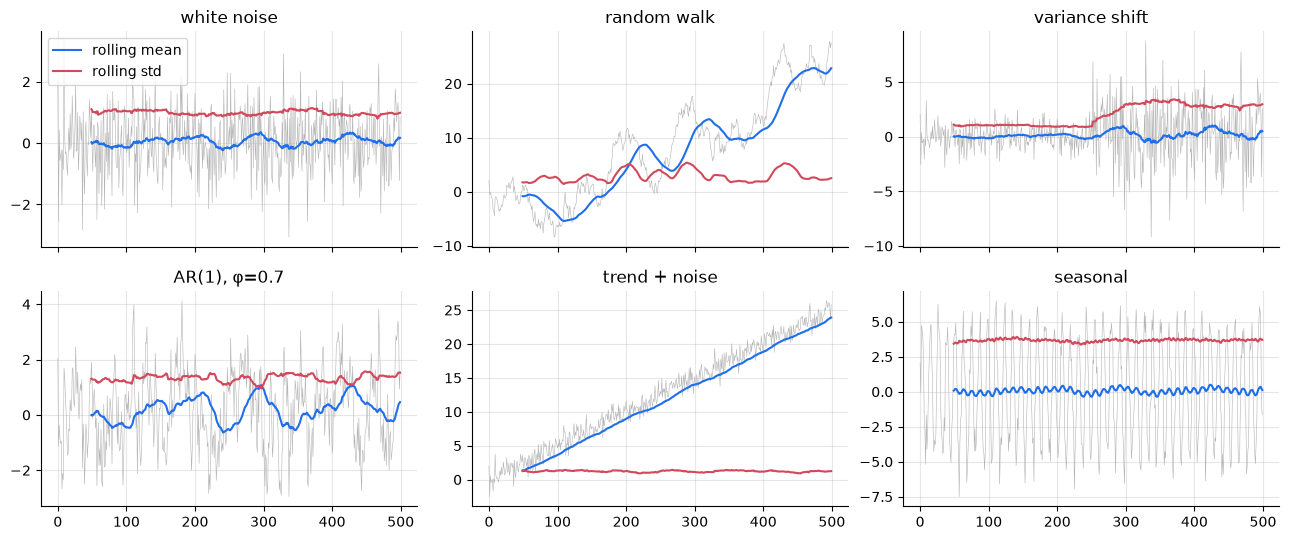

In [5]:
window = 50
fig, axes = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True)
for ax, name in zip(axes.flat, ["white noise", "random walk", "variance shift",
                                "AR(1), φ=0.7", "trend + noise", "seasonal"]):
    s = gallery[name]
    ax.plot(s, lw=0.4, color="0.7")
    ax.plot(s.rolling(window).mean(), label="rolling mean")
    ax.plot(s.rolling(window).std(), label="rolling std")
    ax.set_title(name)
axes[0, 0].legend(loc="upper left")
fig.tight_layout();

The rolling mean exposes the random walk and the trend. The rolling standard deviation exposes the variance shift. The seasonal series is subtler: a 50-step window averages over about four cycles, so the seasonal swing cancels out and both lines look flat. **A window that spans whole seasonal cycles hides seasonality**, so use a decomposition (chapter 02) for that.

---
## 6. Formal tests: ADF and KPSS

The two standard tests ask *opposite* questions, which is exactly why you should use them together.

**Augmented Dickey–Fuller (ADF).** It fits

$$\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1} + \sum_{j=1}^{p} \delta_j\, \Delta y_{t-j} + \varepsilon_t$$

and tests whether $\gamma = 0$, which is the same as $\phi = 1$. The lagged differences soak up short-term autocorrelation, and statsmodels picks $p$ automatically.
- **Null hypothesis:** the series has a **unit root** (non-stationary).
- A small p-value rejects the unit root: evidence *for* stationarity.

**KPSS.** It asks whether the series' deviations from a constant (or a trend) accumulate into something that wanders.
- **Null hypothesis:** the series **is stationary**.
- A small p-value rejects stationarity: evidence *against* it.

Both take a `regression` argument that sets the kind of stationarity being tested. `"c"` means stationary around a constant mean, and `"ct"` means stationary around a **linear trend**. Choosing the wrong one gives confidently wrong answers, as you'll see below.

| | **KPSS: don't reject** | **KPSS: reject** |
|---|---|---|
| **ADF: reject** | ✅ stationary | ⚠️ conflict: often fast mean reversion around a drifting level |
| **ADF: don't reject** | ❓ inconclusive: often too little data | ❌ unit root |

`tsutils.stationarity_tests` runs both and reads the table for you. It builds on `tsutils.adf_pvalue` and `tsutils.kpss_pvalue`, thin wrappers around statsmodels' `adfuller` and `kpss` that return just the p-value and work across statsmodels versions. One quirk to know: KPSS p-values come from a lookup table, so statsmodels **clips them to the range 0.01–0.10**. A reported 0.10 means "0.10 or larger".

In [6]:
report = pd.concat({
    "constant (c)": gallery.apply(tsutils.stationarity_tests, regression="c").T,
    "trend (ct)": gallery.apply(tsutils.stationarity_tests, regression="ct").T,
}, axis=1)
report

constant (c)                    trend (ct)         \
                      ADF p KPSS p     verdict      ADF p KPSS p   
white noise             0.0    0.1  stationary        0.0    0.1   
AR(1), φ=0.7            0.0    0.1  stationary        0.0    0.1   
random walk           0.918   0.01   unit root      0.122  0.035   
trend + noise         0.961   0.01   unit root        0.0    0.1   
variance shift          0.0    0.1  stationary        0.0    0.1   
seasonal                0.0    0.1  stationary        0.0    0.1   

                                  
                         verdict  
white noise     trend-stationary  
AR(1), φ=0.7    trend-stationary  
random walk            unit root  
trend + noise   trend-stationary  
variance shift  trend-stationary  
seasonal        trend-stationary

Read the table row by row, and compare each verdict with the answer in section 2:

- **White noise and AR(1)** are correctly called stationary. Autocorrelation doesn't fool the tests. (Under `"ct"` they come out "trend-stationary", which is also correct: a flat line is a trend with slope zero.)
- **Random walk:** correctly called a unit root.
- **Trend + noise:** with `"c"` it's called a **unit root**, which is wrong. The tests were asked about a constant mean, and a series with a trend certainly doesn't have one. With `"ct"` it's correctly identified as **trend-stationary**. If you can see a trend, test with `"ct"`.
- **Variance shift and seasonal:** both come out **stationary**, and both are wrong. ADF and KPSS are tests about *persistence*, meaning whether shocks accumulate. They were never designed to detect a change in variance or a deterministic seasonal pattern. The rolling standard deviation and the decomposition from chapter 02 catch what these tests can't.

> **The main lesson:** a test result is an answer to one narrow question. Plots, decompositions and domain knowledge answer the rest.

---
## 7. How reliable is the ADF test?

A test has two error rates worth knowing:

- **Size:** how often it *wrongly* rejects when the null is true. With $\alpha = 0.05$ this should be about 5%.
- **Power:** how often it *correctly* rejects when the null is false. We want this high.

We can measure both by simulation. We generate many AR(1) series with a known $\phi$, run ADF on each, and record how often it rejects the unit root. At $\phi = 1$ that rate is the size, and for $\phi < 1$ it's the power.

In [7]:
def adf_rejection_rate(phi, n, reps=200, alpha=0.05, burn_in=100, seed=0):
    """Share of simulated AR(1) series (length n) for which ADF rejects a unit root."""
    shocks = np.random.default_rng(seed).normal(size=(reps, n + burn_in))
    series = ar1(shocks, phi)[:, burn_in:]          # drop the start-up period
    return np.mean([tsutils.adf_pvalue(s) < alpha for s in series])

phis = [1.0, 0.99, 0.95, 0.9, 0.8]
lengths = [100, 250, 500]
power = pd.DataFrame(
    [[adf_rejection_rate(phi, n_obs) for n_obs in lengths] for phi in phis],
    index=pd.Index(phis, name="true φ"),
    columns=pd.Index(lengths, name="series length"),
)
power.style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0, vmax=1)

series length,100,250,500
true φ,,,
1.000000,5%,5%,5%
0.990000,7%,6%,12%
0.950000,16%,45%,94%
0.900000,40%,96%,100%
0.800000,87%,100%,100%


The first row is the test's **size**. It sits close to the promised 5%, so the test is honest about false alarms. The other rows show its **power**, which is where the trouble is:

- At $\phi = 0.95$, a perfectly stationary series with a half-life of about 13 steps, ADF with 100 observations **usually fails to notice**. With 500 it almost always does.
- At $\phi = 0.99$ it is nearly powerless at any of these lengths.

So "ADF did not reject" is **weak evidence**. It often just means "not enough data to tell a slowly reverting series from a random walk". That's the whole reason to pair it with KPSS, whose null is the opposite, and not to treat either p-value as a verdict on its own.

---
## 8. Making a series stationary

The right transformation depends on **why** the series is non-stationary. Using the wrong one creates new problems.

### 8a. Differencing removes a unit root

The **first difference** is $\Delta y_t = y_t - y_{t-1}$ (in pandas, `s.diff()`). For a random walk, $\Delta y_t = \varepsilon_t$: differencing gives back exactly the white-noise shocks.

In [8]:
walk = gallery["random walk"]
pd.DataFrame({
    "random walk": tsutils.stationarity_tests(walk),
    "differenced": tsutils.stationarity_tests(walk.diff()),
}).T

,ADF p,KPSS p,verdict
random walk,0.918,0.01,unit root
differenced,0.0,0.1,stationary


### 8b. Detrend a trend-stationary series; don't difference it

What if we difference the *trend + noise* series instead? $\Delta y_t = 0.05 + \varepsilon_t - \varepsilon_{t-1}$. It's stationary, but we've injected an artificial pattern: each shock now appears twice, once with a plus sign and once with a minus. That gives a lag-1 autocorrelation of exactly $-0.5$ in theory. This is **over-differencing**, and it's the classic sign that you've differenced a series that didn't need it.

The better tool is **detrending**: fit the trend and subtract it.

In [9]:
trendy = gallery["trend + noise"]
slope, intercept = np.polyfit(t, trendy, deg=1)
detrended = trendy - (intercept + slope * t)
differenced = trendy.diff().dropna()

pd.DataFrame({
    "lag-1 autocorrelation": [detrended.autocorr(1), differenced.autocorr(1)],
    "variance": [detrended.var(), differenced.var()],
}, index=["detrended", "differenced"])

,lag-1 autocorrelation,variance
detrended,-0.029,1.002
differenced,-0.522,2.055


Detrending recovers noise with no autocorrelation and the original variance (≈ 1). Differencing produces a lag-1 autocorrelation near −0.5 and **doubles** the variance, adding noise instead of removing it.

> **Rule of thumb:** a strongly negative lag-1 autocorrelation (around −0.5 or below) after differencing suggests you've over-differenced.

### 8c. Seasonal differencing

A **seasonal difference** subtracts the value one full cycle ago, $y_t - y_{t-m}$ (`s.diff(m)`). It removes a stable seasonal pattern, and it removes a unit root at the seasonal lag. Let's apply the options to the Mauna Loa CO₂ series from chapter 02.

,ADF p,KPSS p,verdict
original,0.999,0.01,unit root
first difference,0.0,0.1,stationary
seasonal difference (12),0.0,0.01,"conflict: fast mean reversion, but level drifts"
both,0.0,0.1,stationary


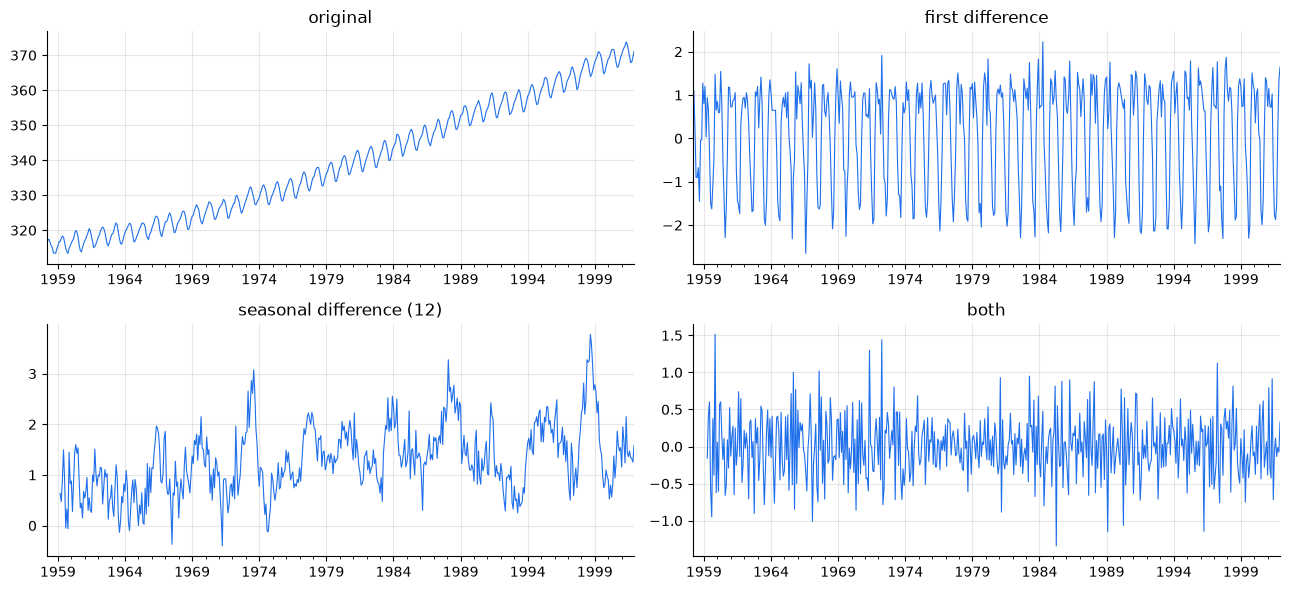

In [10]:
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()

versions = {
    "original": co2,
    "first difference": co2.diff(),
    "seasonal difference (12)": co2.diff(12),
    "both": co2.diff(12).diff(),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, (name, s) in zip(axes.flat, versions.items()):
    s.plot(ax=ax, lw=0.8, title=name)
fig.tight_layout()

pd.DataFrame({name: tsutils.stationarity_tests(s) for name, s in versions.items()}).T

There's a lot in this table:

- **Original:** a unit root, as expected for a series that trends upward for 40 years.
- **First difference:** the tests say *stationary*, but the plot plainly shows the seasonal wave is still there. It's the same blind spot as in section 6.
- **Seasonal difference:** the seasonal pattern is gone, but KPSS still objects. $y_t - y_{t-12}$ is the **year-on-year growth**, and the plot shows CO₂'s growth rate itself creeping upward over the decades. The *rise is accelerating*. (The spikes in growth line up with strong El Niño years such as 1972–73, 1987–88 and 1997–98, when warmer tropics release extra CO₂.)
- **Both:** stationary by every measure.

So CO₂ needs **one regular difference and one seasonal difference**. When we reach SARIMA in chapter 07, those are exactly its $d = 1$ and $D = 1$.

### 8d. Logs for level-dependent variance

If the size of the fluctuations grows **with the level**, as in chapter 02's multiplicative series, take logs *before* differencing. $\Delta \log y_t$ is approximately the **percentage change**, a very natural scale for prices, populations and pollution. A log can't fix variance that jumps for reasons unrelated to the level, like the *variance shift* series. That needs a model of changing volatility, which is beyond this course.

---
## 9. Beijing: what kind of series is PM2.5?

Now the running dataset. We'll use daily means on the log scale (chapter 01 showed the heavy upper tail) and require at least 18 hourly readings per day.

ADF p                                                  0.0
KPSS p                                                0.01
verdict    conflict: fast mean reversion, but level drifts
dtype: object

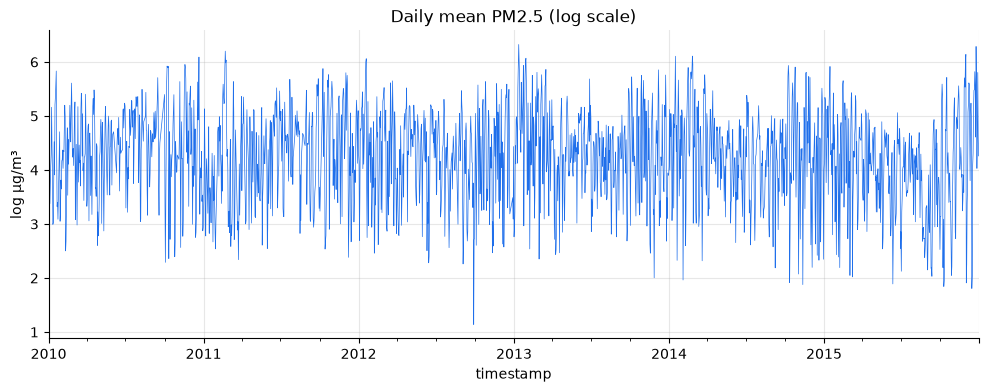

In [11]:
pm = tsutils.load_beijing()["pm25"].interpolate(method="time", limit=3, limit_area="inside")
daily = pm.resample("D").agg(["mean", "count"])
log_pm = np.log(daily["mean"].where(daily["count"] >= 18)).interpolate(limit_direction="both")

log_pm.plot(lw=0.5, title="Daily mean PM2.5 (log scale)", ylabel="log µg/m³")
tsutils.stationarity_tests(log_pm)

**A conflict.** ADF firmly rejects a unit root, while KPSS rejects stationarity. Both can be right at once, because they're sensitive to different features. Let's look at each in turn.

**How fast does the series revert?** The autocorrelation function is the correlation of the series with itself at each lag. It drops to nearly zero within about three days.

In [12]:
pd.Series(acf(log_pm, nlags=7)[1:], index=pd.RangeIndex(1, 8, name="lag (days)"), name="autocorrelation")

lag (days)
1    0.527
2    0.167
3    0.032
4   -0.003
5    0.013
6    0.031
7    0.034
Name: autocorrelation, dtype: float64

In [13]:
phi = log_pm.autocorr(1)
print(f"lag-1 autocorrelation φ ≈ {phi:.2f}  ->  half-life ≈ {np.log(0.5) / np.log(phi):.1f} days")

lag-1 autocorrelation φ ≈ 0.53  ->  half-life ≈ 1.1 days


That's a strongly **mean-reverting** series. A pollution anomaly loses half its effect in about a day. This is what ADF is detecting.

**Is the level itself constant?** Compare yearly means:

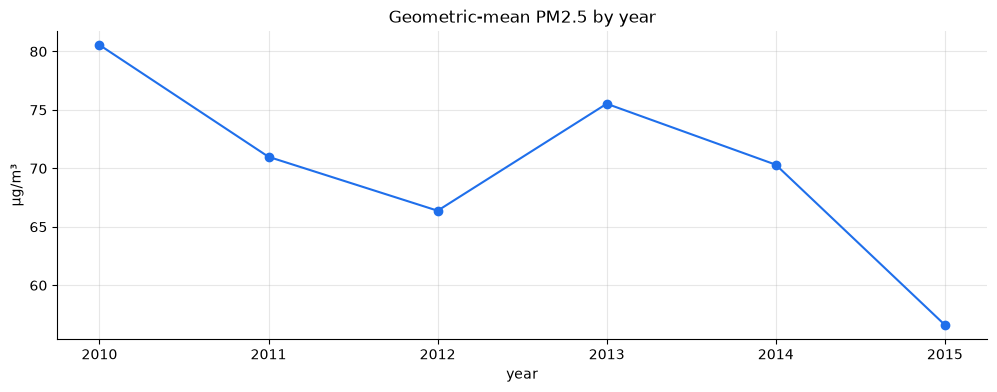

In [14]:
yearly = log_pm.groupby(log_pm.index.year).mean()
ax = np.exp(yearly).plot(marker="o", title="Geometric-mean PM2.5 by year", ylabel="µg/m³")
ax.set_xlabel("year");

In [15]:
pd.DataFrame({
    "all years, constant (c)": tsutils.stationarity_tests(log_pm, regression="c"),
    "all years, trend (ct)": tsutils.stationarity_tests(log_pm, regression="ct"),
    "2010–2014 only, constant (c)": tsutils.stationarity_tests(log_pm[:"2014"], regression="c"),
}).T

,ADF p,KPSS p,verdict
"all years, constant (c)",0.0,0.01,"conflict: fast mean reversion, but level drifts"
"all years, trend (ct)",0.0,0.068,trend-stationary
"2010–2014 only, constant (c)",0.0,0.1,stationary


From 2010 to 2014 the level wobbles between about 65 and 80 µg/m³ with no clear direction. Then **2015 drops well below that range**. That downward shift at the end is what KPSS objects to. Allow for a trend, or leave out 2015, and the conflict disappears.

So the diagnosis is **fast mean reversion around a slowly drifting level**. Two practical consequences follow:

1. **Don't difference this series.** It doesn't have a unit root, and differencing would over-difference it (Exercise 1). The drifting level should be *modelled*, with a trend term or by giving recent data more weight, not differenced away.
2. **Expect a short forecasting horizon.** With a half-life of about a day, today's conditions say a lot about tomorrow and very little about next week. Beyond a few days, any sensible forecast falls back towards the typical level for the season. This will show up clearly in the forecasting chapters.

---
## Exercises

### Exercise 1: Over-differencing, for real
Difference `log_pm` once. Compute the lag-1 autocorrelation of the differenced series and run `tsutils.stationarity_tests` on it. Compare with the undifferenced series. What does the sign of the lag-1 autocorrelation tell you?

<details><summary>Solution</summary>

```python
diffed = log_pm.diff().dropna()
print(f"lag-1 autocorrelation: original {log_pm.autocorr(1):.2f}, differenced {diffed.autocorr(1):.2f}")
print(f"variance: original {log_pm.var():.3f}, differenced {diffed.var():.3f}")
tsutils.stationarity_tests(diffed)
```
The differenced series passes both tests, but its lag-1 autocorrelation turns **negative**, and its variance barely falls: with a half-life of a day, most of each day's value is fresh news anyway. The negative sign is the over-differencing signature from section 8b. It's weaker than −0.5 because the original isn't white noise around a trend, but it points the same way. Passing the tests doesn't make a transformation *right*.
</details>

### Exercise 2: Check the test's size yourself
Simulate 500 random walks of length 200 and run `tsutils.adf_pvalue` on each. What share of them does ADF (wrongly) call stationary at $\alpha = 0.05$? Now do the same for KPSS on 500 series of white noise. Does each test's false-alarm rate match its promise?

<details><summary>Solution</summary>

```python
sim = np.random.default_rng(11).normal(size=(500, 200))
adf_false = np.mean([tsutils.adf_pvalue(w) < 0.05 for w in ar1(sim, 1.0)])
kpss_false = np.mean([tsutils.kpss_pvalue(w) < 0.05 for w in sim])

print(f"ADF false alarms on random walks: {adf_false:.1%}")
print(f"KPSS false alarms on white noise: {kpss_false:.1%}")
```
Both should come out near 5%, with some simulation noise. The tests are honest about false alarms. Their weakness is **power** (section 7), not size.
</details>

### Exercise 3: Random walk with drift
Simulate $y_t = 0.2 + y_{t-1} + \varepsilon_t$ for 500 steps: a random walk that also trends upward. Run the tests with `regression="c"` and with `"ct"`. Can the `"ct"` setting tell this apart from the *trend + noise* series? What transformation makes it stationary?

<details><summary>Solution</summary>

```python
drift_walk = pd.Series(ar1(0.2 + rng.normal(size=500), 1.0))
drift_walk.plot(title="random walk with drift")
pd.DataFrame({
    "c": tsutils.stationarity_tests(drift_walk, regression="c"),
    "ct": tsutils.stationarity_tests(drift_walk, regression="ct"),
    "differenced": tsutils.stationarity_tests(drift_walk.diff()),
}).T
```
Even with `"ct"`, the tests should still find a unit root (rerun with other seeds to check it isn't luck). The trend here is made of accumulated shocks, not a fixed line, so detrending can't remove the wandering. Differencing gives $0.2 + \varepsilon_t$, which is stationary. **Trend-stationary** and **difference-stationary** series can look alike on a plot, and the tests with `"ct"` are how you tell them apart.
</details>

### Exercise 4: Spurious correlation
Generate 1,000 *pairs* of **independent** random walks (length 200) and record the correlation within each pair. Then do the same for their first differences. Plot both distributions. Why does this matter whenever you relate one time series to another, say PM2.5 and temperature?

<details><summary>Solution</summary>

```python
pairs = ar1(np.random.default_rng(5).normal(size=(1000, 2, 200)), 1.0)
level_corr = [np.corrcoef(a, b)[0, 1] for a, b in pairs]
diff_corr = [np.corrcoef(np.diff(a), np.diff(b))[0, 1] for a, b in pairs]

ax = pd.DataFrame({"levels": level_corr, "differences": diff_corr}).plot.hist(
    bins=40, alpha=0.6, title="Correlation between independent series")
ax.set_xlabel("correlation")
print(f"share of level pairs with |corr| > 0.5: {np.mean(np.abs(level_corr) > 0.5):.0%}")
```
The walks are independent by construction, yet their *levels* often correlate strongly, positively or negatively, because two wandering series are bound to share some stretches of up and down. Their *differences* correlate close to zero, as they should. This is **spurious correlation**. Before reading anything into a correlation between two series, make sure both are stationary (or model them properly), or you may be measuring coincidence.
</details>

---
## Key takeaways

- **Stationary** means constant mean, constant variance, and autocorrelation that depends only on the lag. **Autocorrelation itself is allowed.**
- A **random walk** ($\phi = 1$) never forgets a shock, and its variance grows without limit. It also produces convincing fake trends. A **mean-reverting** process forgets at a rate summarised by its **half-life**.
- **ADF** (null: unit root) and **KPSS** (null: stationary) ask opposite questions, so use them together. Pick `regression="ct"` when there's a visible trend.
- Both tests are **blind to variance changes and deterministic seasonality**, and ADF has **low power** near $\phi = 1$. Always plot.
- **Difference** a unit root, **detrend** a trend-stationary series, **seasonally difference** a seasonal series, and take **logs** when variance grows with the level. A lag-1 autocorrelation near −0.5 after differencing means you've over-differenced.
- Daily PM2.5 is **mean-reverting (half-life ≈ 1 day) around a slowly drifting level**. Don't difference it. Expect short-horizon forecasts to be the useful ones.

**Next:** *04 · Baselines and Honest Evaluation*. Before building any real model, we'll set up the yardsticks: simple forecasts every model must beat, error metrics that can be compared across series, and a backtest that never lets the model see the future.